# SARSA Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement SARSA and compare with Q-learning
- Understand on-policy vs off-policy

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 2**.

---


## Lesson Brief

This lesson introduces **SARSA**, an on-policy alternative to Q-learning.

Students will compare how learning changes when updates depend on the action the agent actually follows, not only the greedy action estimate.

Why this matters: SARSA helps students understand that not all value-learning methods make the same assumptions about behavior and learning.

It is also a good lesson for discussing safer or more conservative learning behavior.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **deeplizard - "How to Code SARSA with Just Numpy"**:
[Watch on YouTube](https://www.youtube.com/watch?v=gJZwXkXDFEI)

Why this pick:
- coding-first explanation.
- Helps students see the on-policy nature of SARSA in a concrete update loop.
- Good companion when comparing SARSA against Q-learning.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- On-policy: learns from the actions actually taken by the current behavior policy.
- Next action: part of the SARSA update target.
- Behavior policy: the policy generating the data.
- Update target: the value the estimate moves toward.
- Exploration-aware learning: updates reflect the fact that the policy is still exploring.

### Quick Check
- Why does SARSA use the next chosen action?
- How can SARSA become more cautious?
- What makes SARSA on-policy?
- Why can exploration change the learned behavior itself?

### Common Mistakes
- Thinking SARSA equals Q-learning.
- Ignoring exploration in the update.
- Missing how the next action changes behavior.
- Forgetting that SARSA learns the value of the policy it is actually following.


## SARSA vs Q-Learning in Plain Language

Students often ask: if both algorithms update action values, why do we need both?

### Q-learning

Q-learning asks:

`What is the best next action I could take from the next state?`

So it learns toward a greedy target, even if the current behavior policy is still exploring.

### SARSA

SARSA asks:

`What action did I actually choose next, and what is its value?`

So the update includes the real next action produced by the current policy.

### Why does this matter?

If the current policy still explores, SARSA learns a value function that already reflects that exploration risk.
This often makes SARSA look more cautious than Q-learning.

### Memory trick

SARSA is named from the update pieces:

- State
- Action
- Reward
- State
- Action

That final action is the clue that the update depends on the next action actually taken.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

"""
AIAT 123 - SARSA Algorithm
SARSA Algorithm
"""

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Show text or numbers in the cell output area under the code.
print("=" * 70)
# Show text or numbers in the cell output area under the code.
print("SARSA Algorithm")
# Show text or numbers in the cell output area under the code.
print("=" * 70)

# Implementation here
# Show text or numbers in the cell output area under the code.
print("\n✅ Notebook ready for implementation!")


SARSA Algorithm

✅ Notebook ready for implementation!


## 🌍 Real-World Worked Example — Inventory Management with SARSA

**Industry context:**
- Amazon uses RL to optimise warehouse robot routing
- Google DeepMind reduced data centre cooling costs by 40% using RL
- Uber uses RL for dynamic surge pricing

We model a simple **inventory replenishment** problem as an MDP and solve it with **SARSA**, so the update reflects the action the policy actually chooses next.

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


SARSA policy suggestion:


  Stock= 0 → RESTOCK
  Stock= 1 → RESTOCK
  Stock= 2 → RESTOCK
  Stock= 3 → RESTOCK
  Stock= 4 → RESTOCK
  Stock= 5 → Do NOT restock
  Stock= 6 → Do NOT restock
  Stock= 7 → Do NOT restock
  Stock= 8 → Do NOT restock
  Stock= 9 → Do NOT restock
  Stock=10 → Do NOT restock


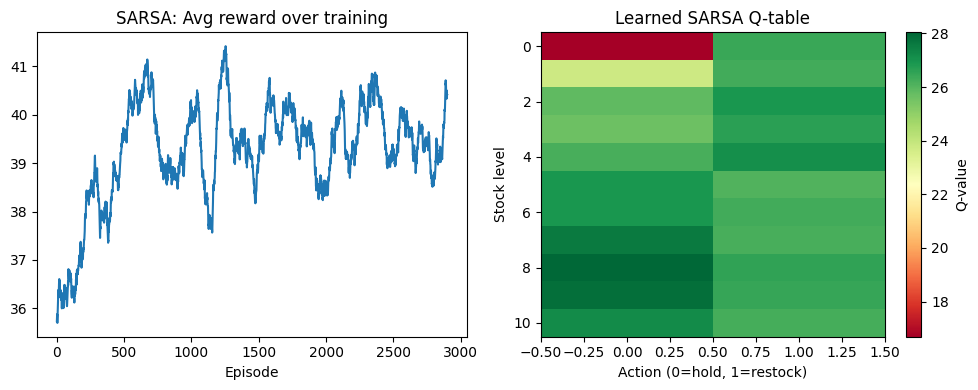

In [2]:
# Worked example: run SARSA on the same inventory environment so the update target stays on-policy.
# Notice that the next chosen action is part of the update, not just the greedy action value.

# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)

# ── Environment: Inventory Management ─────────────────────────────────────
# State: stock level 0..10. Action: 0=don't restock, 1=restock (+5 units).
# Each day: sell 0-3 units (random). Reward: +1 per unit sold, -2 if out of stock.
# Save a value in a name so the next lines can read it.
MAX_STOCK = 10
# Another assignment—same idea: store a value for the lines below.
n_states, n_actions = MAX_STOCK + 1, 2

# Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def step(state, action):
    # Save a value in a name so the next lines can read it.
    new_s = min(state + action * 5, MAX_STOCK)
    # Another assignment—same idea: store a value for the lines below.
    demand = np.random.randint(0, 4)
    # Another assignment—same idea: store a value for the lines below.
    sold = min(new_s, demand)
    # Unpack the one-step model output from transition(state, action).
    reward = sold - (2 if demand > new_s else 0) - (0.5 * action)
    # Save a value in a name so the next lines can read it.
    new_s = max(new_s - demand, 0)
    # Send a value back to whoever called this function.
    return new_s, reward

# Function `choose_action` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: q_table, state, eps.
def choose_action(q_table, state, eps):
    # Send a value back to whoever called this function.
    return np.random.randint(n_actions) if np.random.rand() < eps else int(np.argmax(q_table[state]))

# ── SARSA ──────────────────────────────────────────────────────────────────
# Save a value in a name so the next lines can read it.
Q = np.zeros((n_states, n_actions))
# Another assignment—same idea: store a value for the lines below.
alpha = 0.1; gamma = 0.95
# Another assignment—same idea: store a value for the lines below.
eps = 1.0; eps_min = 0.05; eps_decay = 0.995
# Unpack the one-step model output from transition(state, action).
rewards_history = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(3000):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = np.random.randint(0, MAX_STOCK + 1)
    # Save a value in a name so the next lines can read it.
    action = choose_action(Q, state, eps)
    # Another assignment—same idea: store a value for the lines below.
    total_r = 0

    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(30):
        # Unpack the one-step model output from transition(state, action).
        next_state, reward = step(state, action)
        # Save a value in a name so the next lines can read it.
        next_action = choose_action(Q, next_state, eps)
        # Another assignment—same idea: store a value for the lines below.
        td_target = reward + gamma * Q[next_state, next_action]
        # Another assignment—same idea: store a value for the lines below.
        Q[state, action] += alpha * (td_target - Q[state, action])
        # Another assignment—same idea: store a value for the lines below.
        state, action = next_state, next_action
        # Another assignment—same idea: store a value for the lines below.
        total_r += reward

    # Add one new item to the end of a list (the list grows in place).
    rewards_history.append(total_r)
    # Save a value in a name so the next lines can read it.
    eps = max(eps * eps_decay, eps_min)

# ── Results ──────────────────────────────────────────────────────────────
# Show text or numbers in the cell output area under the code.
print("SARSA policy suggestion:")
# Start a loop: repeat the indented block once per item in the sequence.
for s in range(11):
    # Save a value in a name so the next lines can read it.
    action_name = ['Do NOT restock', 'RESTOCK'][int(np.argmax(Q[s]))]
    # Show text or numbers in the cell output area under the code.
    print(f"  Stock={s:2d} → {action_name}")

# Save a value in a name so the next lines can read it.
ma = np.convolve(rewards_history, np.ones(100) / 100, mode='valid')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10,4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,1)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ma)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("SARSA: Avg reward over training")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.imshow(Q, aspect='auto', cmap='RdYlGn')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.colorbar(label="Q-value")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Action (0=hold, 1=restock)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Stock level")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Learned SARSA Q-table")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()


In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


## 📝 Summary

You implemented **SARSA** and **Q-Learning** — two core temporal-difference algorithms. The key difference: Q-Learning is off-policy (learns optimal regardless of behavior) while SARSA is on-policy. Both power real applications like elevator scheduling, traffic signal optimization, and game-playing agents.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


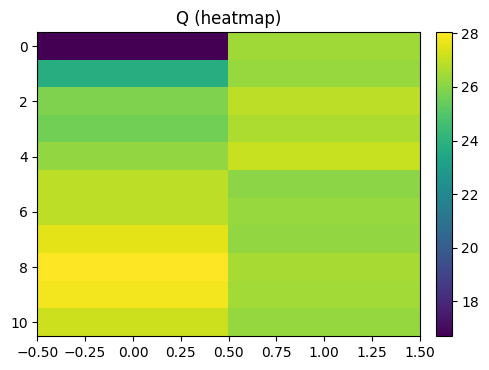

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** SARSA learns from the action the agent actually takes, so it reflects the behavior policy more directly than Q-learning does.

**If students remember one idea:** On-policy learning means the update follows the path the current policy really experienced.

**Quick check before moving on:**
- Can you explain the structural difference between the SARSA and Q-learning update targets?
- Can you describe why SARSA can behave more cautiously during exploration?

**Bridge to the next step:** After this comparison, students can better appreciate when prediction and control updates should reflect actual behavior versus greedy targets.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**At a glance:** The next cell uses a **random** policy on FrozenLake. **Not reaching the goal tile `G` is normal and intended**—the point is to see the **API loop** (state → action → reward → next state) in motion, not to prove a solved policy. If the episode ends in a hole or times out, the demo is still doing its job.

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.


Teaching note: random FrozenLake rollouts may not reach G—this is expected. Read state→action→reward over time, not 'did it win?'.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=16 | term=True | trunc=False


objc[77086]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114634138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114b309c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77086]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114634188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114b30a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77086]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114633c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114b30a68). T

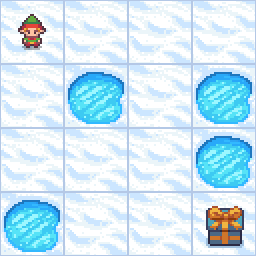

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

print(
    "Teaching note: random FrozenLake rollouts may not reach G—this is expected. "
    "Read state→action→reward over time, not 'did it win?'."
)

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
